In [3]:
import pandas as pd


In [4]:

transaction_df = pd.read_csv("train_transaction.csv")
print(transaction_df.head)


<bound method NDFrame.head of         TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ... V330  V331  V332 

In [5]:
print(transaction_df.shape)

(590540, 394)


In [6]:

identity_df = pd.read_csv("train_identity.csv")

In [7]:
print(identity_df.shape)

(144233, 41)


In [8]:
print(transaction_df.columns.intersection(identity_df.columns))

Index(['TransactionID'], dtype='object')


In [9]:

df = transaction_df.merge(
    identity_df,
    on="TransactionID",
    how="left"
)

In [10]:

print("Merged shape:", df.shape)

Merged shape: (590540, 434)


In [11]:

assert len(transaction_df) == len(df)

In [12]:
df["has_identity"] = df["id_01"].notna()

In [13]:

print("\nIdentity coverage:")
print(df["has_identity"].value_counts())


Identity coverage:
has_identity
False    446307
True     144233
Name: count, dtype: int64


In [14]:
print("\nIdentity coverage percentage:")
print(df["has_identity"].value_counts(normalize=True) * 100)


Identity coverage percentage:
has_identity
False    75.576083
True     24.423917
Name: proportion, dtype: float64


In [15]:

print(df.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo', 'has_identity'],
      dtype='object', length=435)


In [16]:
print(df.head)

<bound method NDFrame.head of         TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ... id_32      id_33 

In [17]:
df.to_csv("merged_dataset.csv", index=False)

In [18]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,True


In [19]:
df.shape

(590540, 435)

In [20]:
df['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [23]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,True


In [24]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 590540
Number of columns: 435


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 435 entries, TransactionID to has_identity
dtypes: bool(1), float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [26]:

print(df["isFraud"].value_counts())

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [27]:
missing_count = df.isnull().sum()

print(missing_count[missing_count > 0].sort_values(ascending=False))

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
          ...  
V309         12
V312         12
V311         12
V310         12
V316         12
Length: 414, dtype: int64


In [28]:

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing[missing["Missing_Count"] > 0]
missing = missing.sort_values(
    "Missing_Percentage",
    ascending=False
)

print(missing)

       Missing_Count  Missing_Percentage
id_24         585793           99.196159
id_25         585408           99.130965
id_07         585385           99.127070
id_08         585385           99.127070
id_21         585381           99.126393
...              ...                 ...
V309              12            0.002032
V312              12            0.002032
V311              12            0.002032
V310              12            0.002032
V316              12            0.002032

[414 rows x 2 columns]


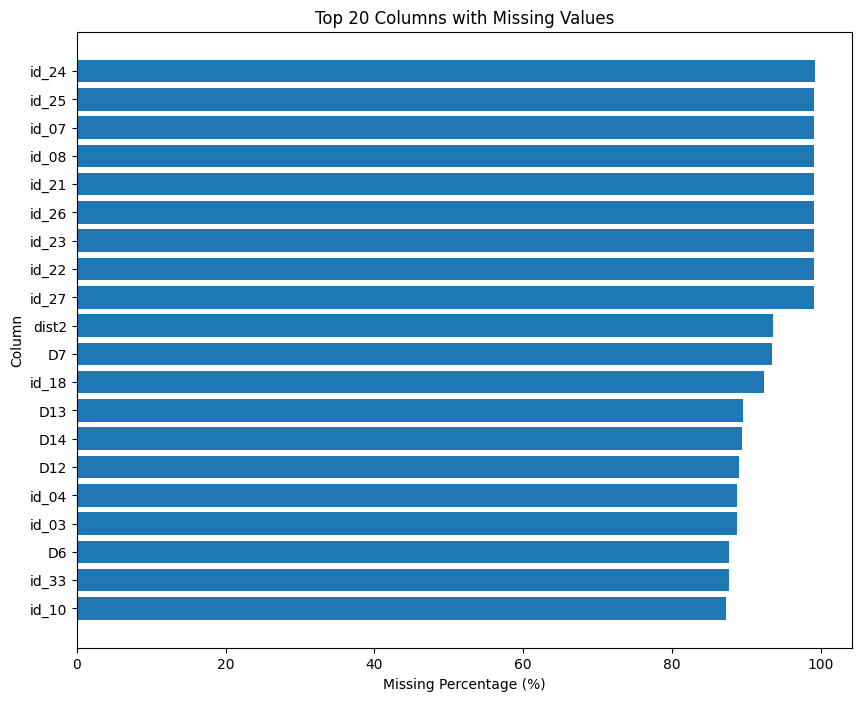

In [29]:
import matplotlib.pyplot as plt

top_missing = missing.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_missing.index[::-1],
    top_missing["Missing_Percentage"][::-1]
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Column")
plt.title("Top 20 Columns with Missing Values")

plt.show()

In [30]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [31]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", duplicate_percentage, "%")

Duplicate percentage: 0.0 %


In [32]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical columns:", len(numeric_cols))

Number of numerical columns: 403


In [33]:

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
id_22,5169.0,1.600271e+01,6.897665e+00,10.000,14.000,14.000,14.00,4.400000e+01
id_24,4747.0,1.280093e+01,2.372447e+00,11.000,11.000,11.000,15.00,2.600000e+01
id_25,5132.0,3.296089e+02,9.746109e+01,100.000,321.000,321.000,371.00,5.480000e+02
id_26,5163.0,1.490703e+02,3.210199e+01,100.000,119.000,149.000,169.00,2.160000e+02


In [34]:
df["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

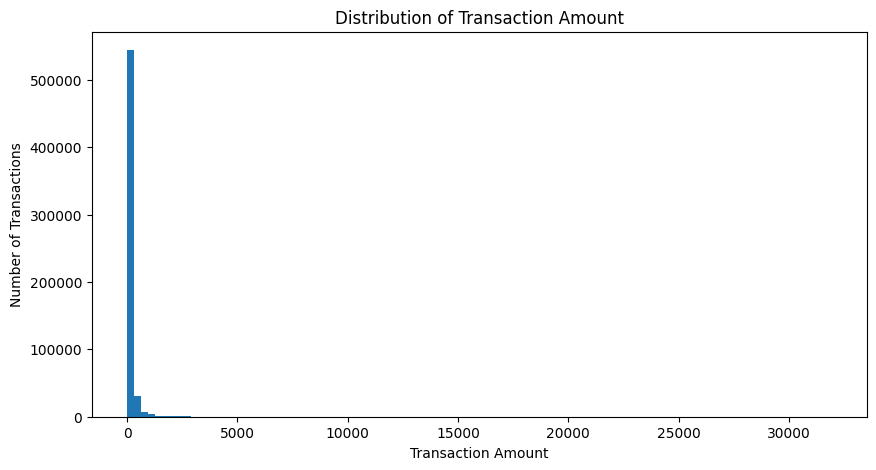

In [35]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["TransactionAmt"].dropna(), bins=100)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transaction Amount")

plt.show()

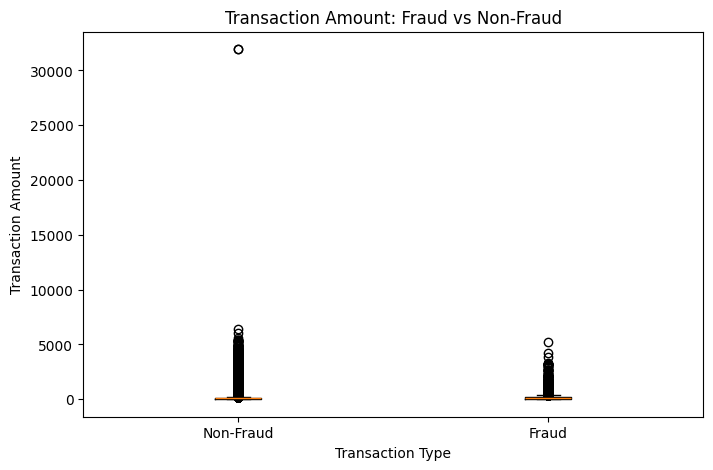

In [36]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df.loc[df["isFraud"] == 0, "TransactionAmt"].dropna(),
        df.loc[df["isFraud"] == 1, "TransactionAmt"].dropna()
    ],
    tick_labels=["Non-Fraud", "Fraud"]
)

plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount: Fraud vs Non-Fraud")

plt.show()

In [37]:

df.groupby("isFraud")["TransactionAmt"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
isFraud,,,,,,
0,569877,134.511665,68.5,239.395078,0.251,31937.391
1,20663,149.244779,75.0,232.212163,0.292,5191.000


In [38]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols.tolist())


Number of categorical columns: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [39]:

print(df["ProductCD"].value_counts())

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


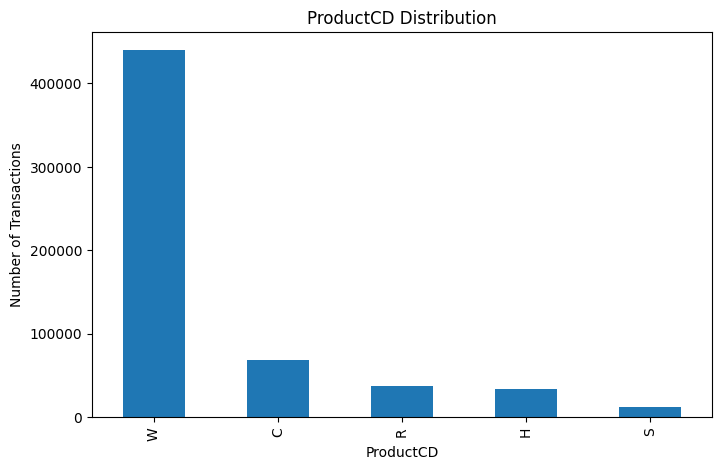

In [40]:
import matplotlib.pyplot as plt

df["ProductCD"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("ProductCD Distribution")
plt.xlabel("ProductCD")
plt.ylabel("Number of Transactions")

plt.show()

In [41]:

fraud_rate = df.groupby("ProductCD")["isFraud"].mean() * 100

print(fraud_rate.sort_values(ascending=False))

ProductCD
C    11.687269
S     5.899553
H     4.766231
R     3.782594
W     2.039939
Name: isFraud, dtype: float64


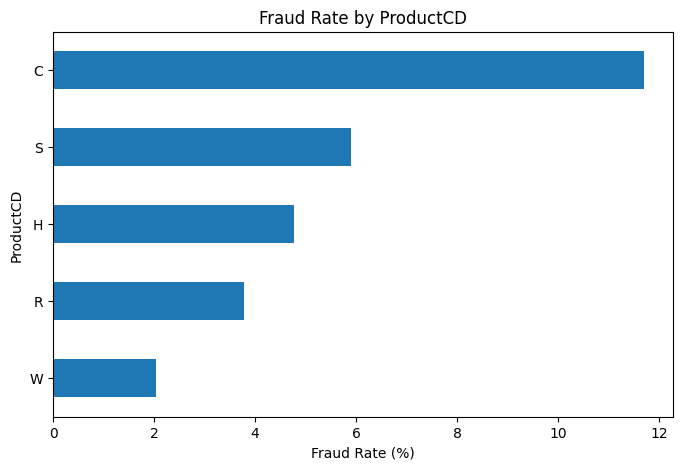

In [42]:
fraud_rate.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Fraud Rate by ProductCD")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("ProductCD")

plt.show()

In [43]:
print(df["card6"].value_counts(dropna=False))

card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64


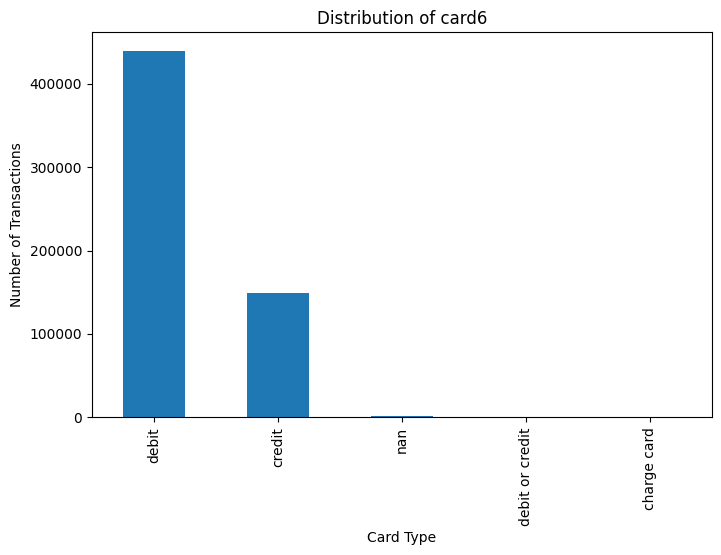

In [44]:
plt.figure(figsize=(8,5))

df["card6"].value_counts(dropna=False).plot(kind="bar")

plt.title("Distribution of card6")
plt.xlabel("Card Type")
plt.ylabel("Number of Transactions")

plt.show()

In [45]:
card6_fraud_rate = df.groupby("card6", dropna=False)["isFraud"].mean() * 100

print(card6_fraud_rate.sort_values(ascending=False))

card6
credit             6.678480
NaN                2.482495
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64


In [46]:

print(df["card4"].value_counts(dropna=False))

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64


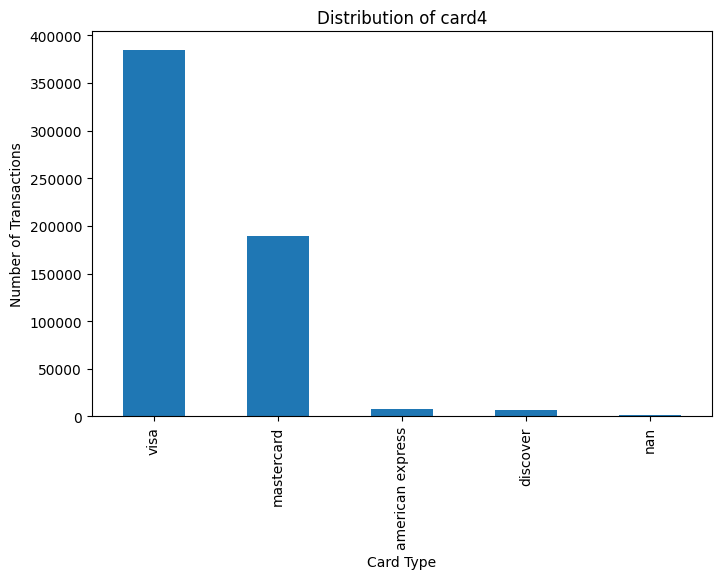

In [47]:
plt.figure(figsize=(8,5))

df["card4"].value_counts(dropna=False).plot(kind="bar")

plt.title("Distribution of card4")
plt.xlabel("Card Type")
plt.ylabel("Number of Transactions")

plt.show()

In [48]:
card4_fraud_rate = df.groupby(
    "card4",
    dropna=False
)["isFraud"].mean() * 100

print(card4_fraud_rate.sort_values(ascending=False))

card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
NaN                 2.599873
Name: isFraud, dtype: float64


In [49]:
print(df["P_emaildomain"].value_counts(dropna=False).head(20))

P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
bellsouth.net      1909
yahoo.com.mx       1543
me.com             1522
cox.net            1393
optonline.net      1011
Name: count, dtype: int64


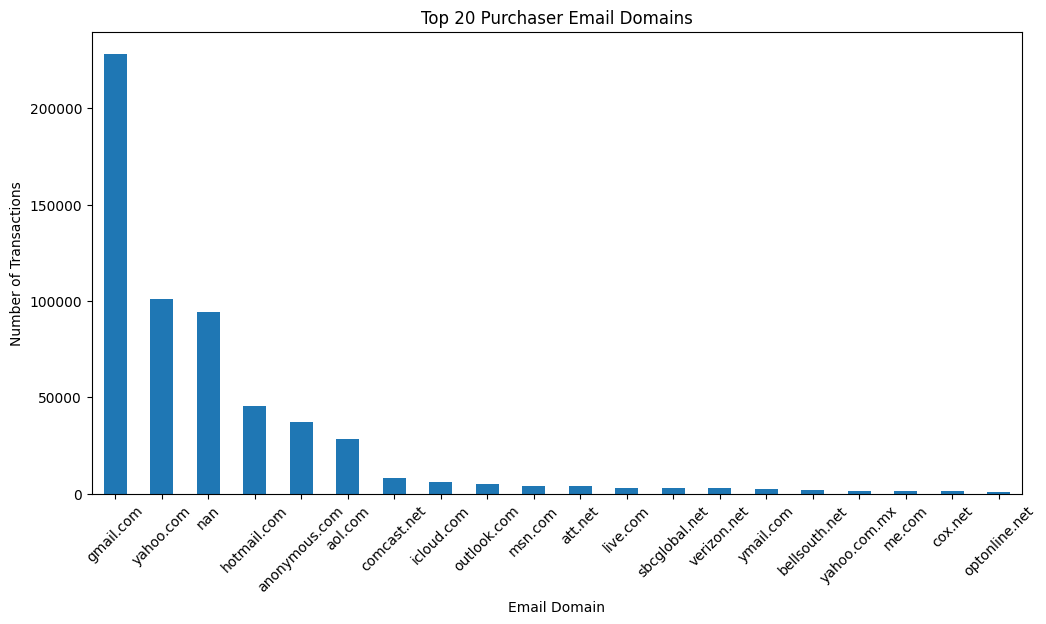

In [50]:
plt.figure(figsize=(12, 6))

df["P_emaildomain"].value_counts(dropna=False).head(20).plot(
    kind="bar"
)

plt.title("Top 20 Purchaser Email Domains")
plt.xlabel("Email Domain")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [51]:
p_email_fraud_rate = (
    df.groupby("P_emaildomain", dropna=False)["isFraud"]
      .mean() * 100
)

print(p_email_fraud_rate.sort_values(ascending=False).head(20))

P_emaildomain
protonmail.com     40.789474
mail.com           18.962433
outlook.es         13.013699
aim.com            12.698413
outlook.com         9.458399
hotmail.es          6.557377
live.com.mx         5.473965
hotmail.com         5.295028
gmail.com           4.354185
yahoo.fr            3.496503
embarqmail.com      3.461538
mac.com             3.211009
icloud.com          3.143450
comcast.net         3.118661
charter.net         3.063725
NaN                 2.953756
frontier.com        2.857143
bellsouth.net       2.776323
live.com            2.762249
frontiernet.net     2.564103
Name: isFraud, dtype: float64


In [52]:
print(df["R_emaildomain"].value_counts(dropna=False).head(20))

R_emaildomain
NaN              453249
gmail.com         57147
hotmail.com       27509
anonymous.com     20529
yahoo.com         11842
aol.com            3701
outlook.com        2507
comcast.net        1812
yahoo.com.mx       1508
icloud.com         1398
msn.com             852
live.com            762
live.com.mx         754
verizon.net         620
me.com              556
sbcglobal.net       552
cox.net             459
outlook.es          433
att.net             430
bellsouth.net       422
Name: count, dtype: int64


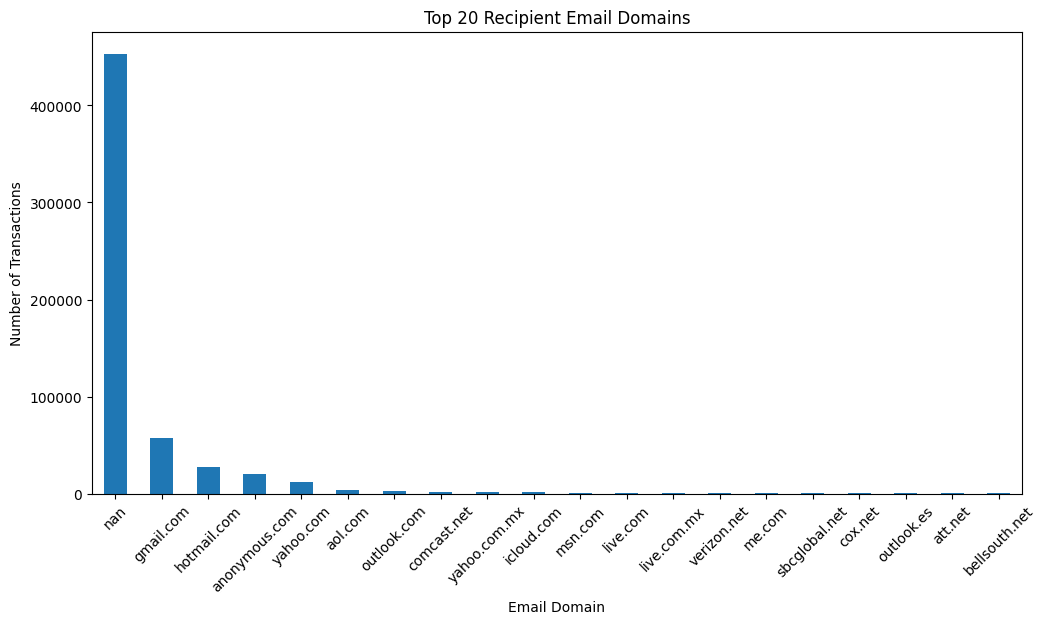

In [53]:
plt.figure(figsize=(12, 6))

df["R_emaildomain"].value_counts(dropna=False).head(20).plot(
    kind="bar"
)

plt.title("Top 20 Recipient Email Domains")
plt.xlabel("Email Domain")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [54]:

r_email_fraud_rate = (
    df.groupby("R_emaildomain", dropna=False)["isFraud"]
      .mean() * 100
)

print(
    r_email_fraud_rate
    .sort_values(ascending=False)
    .head(20)
)

R_emaildomain
protonmail.com    95.121951
mail.com          37.704918
netzero.net       22.222222
outlook.com       16.513761
outlook.es        13.163972
icloud.com        12.875536
gmail.com         11.918386
hotmail.com        7.779272
earthlink.net      7.594937
hotmail.es         6.849315
live.com.mx        5.835544
yahoo.com          5.151157
live.com           4.986877
rocketmail.com     4.347826
suddenlink.net     4.000000
charter.net        3.937008
ymail.com          3.864734
yahoo.fr           3.649635
yahoo.es           3.508772
aol.com            3.485544
Name: isFraud, dtype: float64


In [55]:
print("Number of unique DeviceInfo values:",
      df["DeviceInfo"].nunique(dropna=True))

Number of unique DeviceInfo values: 1786


In [56]:
print(
    df["DeviceInfo"]
      .value_counts(dropna=False)
      .head(20)
)

DeviceInfo
NaN                            471874
Windows                         47722
iOS Device                      19782
MacOS                           12573
Trident/7.0                      7440
rv:11.0                          1901
rv:57.0                           962
SM-J700M Build/MMB29K             549
SM-G610M Build/MMB29K             461
SM-G531H Build/LMY48B             410
rv:59.0                           362
SM-G935F Build/NRD90M             334
SM-G955U Build/NRD90M             328
SM-G532M Build/MMB29T             316
ALE-L23 Build/HuaweiALE-L23       312
SM-G950U Build/NRD90M             290
SM-G930V Build/NRD90M             274
rv:58.0                           269
rv:52.0                           256
SAMSUNG                           235
Name: count, dtype: int64


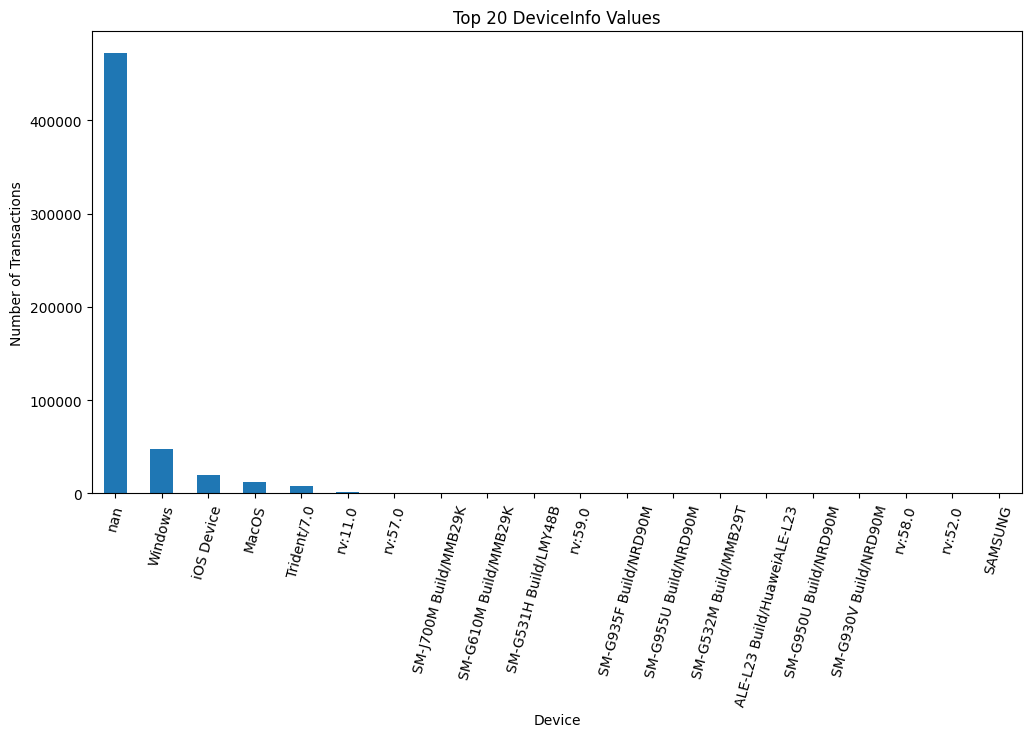

In [57]:
plt.figure(figsize=(12, 6))

df["DeviceInfo"].value_counts(dropna=False).head(20).plot(
    kind="bar"
)

plt.title("Top 20 DeviceInfo Values")
plt.xlabel("Device")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)

plt.show()

In [58]:
device_fraud_rate = (
    df.groupby("DeviceInfo", dropna=False)["isFraud"]
      .mean() * 100
)

print(
    device_fraud_rate
    .sort_values(ascending=False)
    .head(20)
)

DeviceInfo
rv:29.0                         100.0
rv:14.0                         100.0
ZTE-Z956                        100.0
iPhone                          100.0
Z835 Build/NMF26V               100.0
Z965 Build/NMF26V               100.0
ZEIA8                           100.0
ZTE-Z835                        100.0
Z813 Build/LMY47O               100.0
XT890 Build/9.8.2I-50_SML-25    100.0
TAB7                            100.0
VS5012 Build/NRD90M             100.0
XT1021                          100.0
XT1609                          100.0
XT1033                          100.0
A5002                           100.0
SM-J700T Build/MMB29K           100.0
SM-G850M                        100.0
A574BL Build/NMF26F             100.0
SM-A300M Build/KTU84P           100.0
Name: isFraud, dtype: float64


In [59]:

print(df["id_30"].value_counts(dropna=False).head(20))

id_30
NaN                 512975
Windows 10           21155
Windows 7            13110
iOS 11.2.1            3722
iOS 11.1.2            3699
Android 7.0           2871
Mac OS X 10_12_6      2559
Mac OS X 10_11_6      2348
iOS 11.3.0            2016
Windows 8.1           1914
Mac OS X 10_10_5      1651
iOS 11.2.6            1647
iOS 10.3.3            1558
Mac OS X 10_13_2      1421
Mac OS X 10_13_1      1211
iOS 11.2.5            1200
Linux                 1136
Android               1079
iOS 11.2.2             902
Mac OS X 10_13_3       860
Name: count, dtype: int64


In [60]:
print("Unique id_30 values:", df["id_30"].nunique(dropna=True))

Unique id_30 values: 75


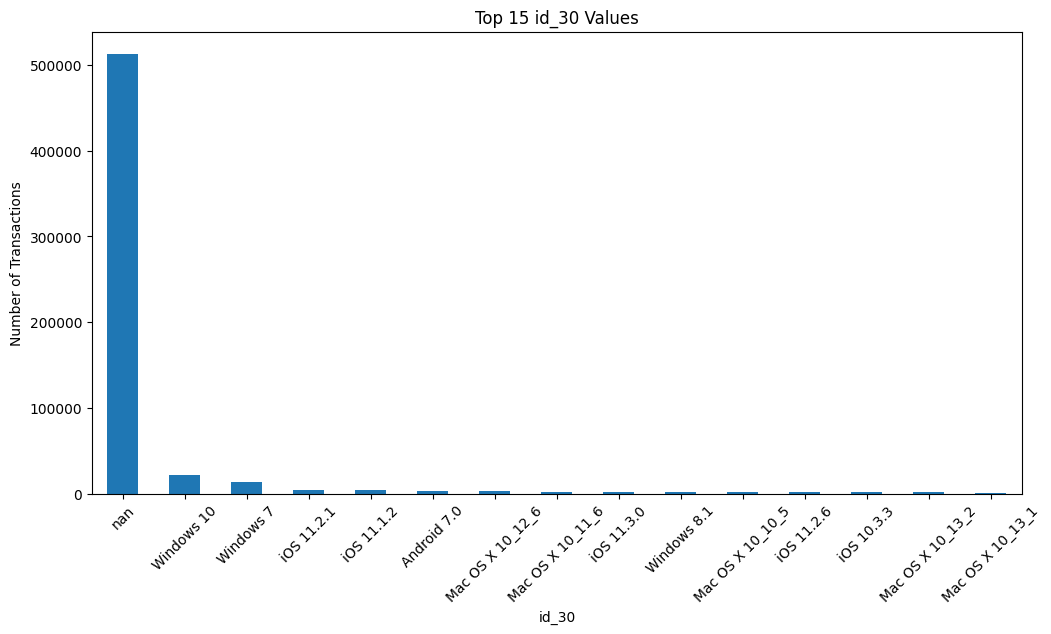

In [61]:
plt.figure(figsize=(12, 6))

df["id_30"].value_counts(dropna=False).head(15).plot(
    kind="bar"
)

plt.title("Top 15 id_30 Values")
plt.xlabel("id_30")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [62]:
id30_fraud_rate = (
    df.groupby("id_30", dropna=False)["isFraud"]
      .mean() * 100
)

print(
    id30_fraud_rate
    .sort_values(ascending=False)
    .head(20)
)

id_30
other               60.000000
Android 5.1.1       28.857143
Android 4.4.2       25.396825
iOS 11.4.0          20.000000
iOS 11.0.1          19.685039
iOS 11.1.0          17.712177
iOS 11.2.5          12.166667
Android 7.1.2       12.121212
iOS 11.2.2          11.751663
Windows 8           11.666667
Mac OS X 10_12_1    11.363636
Android 7.1.1       10.634921
Android             10.565338
Windows Vista        9.349593
iOS 11.0.0           9.027778
iOS 10.2.1           8.771930
Android 6.0.1        8.480565
iOS 11.2.0           8.450704
iOS 10.2.0           8.053691
iOS 11.0.2           7.831325
Name: isFraud, dtype: float64


In [63]:
c_cols = [col for col in df.columns if col.startswith("C")]
d_cols = [col for col in df.columns if col.startswith("D")]
v_cols = [col for col in df.columns if col.startswith("V")]

print("C features:", len(c_cols))
print("D features:", len(d_cols))
print("V features:", len(v_cols))

C features: 14
D features: 17
V features: 339


In [64]:
print("C features missing %:")
print(df[c_cols].isnull().mean().mean() * 100)

print("D features missing %:")
print(df[d_cols].isnull().mean().mean() * 100)

print("V features missing %:")
print(df[v_cols].isnull().mean().mean() * 100)

C features missing %:
0.0
D features missing %:
60.49001014027042
V features missing %:
43.038468965907214


In [65]:
c_cols = [col for col in df.columns if col.startswith("C") and col[1:].isdigit()]
d_cols = [col for col in df.columns if col.startswith("D") and col[1:].isdigit()]
v_cols = [col for col in df.columns if col.startswith("V") and col[1:].isdigit()]

In [66]:
print("Top C features by standard deviation:")
print(df[c_cols].std().sort_values(ascending=False).head(10))

print("\nTop D features by standard deviation:")
print(df[d_cols].std().sort_values(ascending=False).head(10))

print("\nTop V features by standard deviation:")
print(df[v_cols].std().sort_values(ascending=False).head(10))

Top C features by standard deviation:
C2     154.668899
C1     133.569018
C13    129.364844
C10     95.581443
C8      95.378574
C11     94.336292
C12     86.666218
C6      71.508467
C4      68.848459
C7      61.727304
dtype: float64

Top D features by standard deviation:
D8     231.663840
D15    202.726660
D4     191.096774
D11    186.042622
D10    182.615225
D2     177.315865
D1     157.660387
D6     143.669253
D14    136.312450
D12    124.274558
dtype: float64

Top V features by standard deviation:
V160    142076.069162
V332     11169.275702
V203      9105.607991
V159      8355.445049
V165      8223.258928
V333      7955.735482
V212      7496.120737
V331      6217.223583
V164      6049.166505
V204      6048.980716
dtype: float64


In [67]:
fraud_corr = (
    df[numeric_cols]
    .corrwith(df["isFraud"])
    .sort_values(ascending=False)
)

print(fraud_corr.head(20))

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
dtype: float64


In [68]:
print(fraud_corr.head(10))
print(fraud_corr.tail(10))

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
dtype: float64
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
dtype: float64


In [69]:

feature = fraud_corr.abs().idxmax()

print("Selected feature:", feature)

Selected feature: isFraud


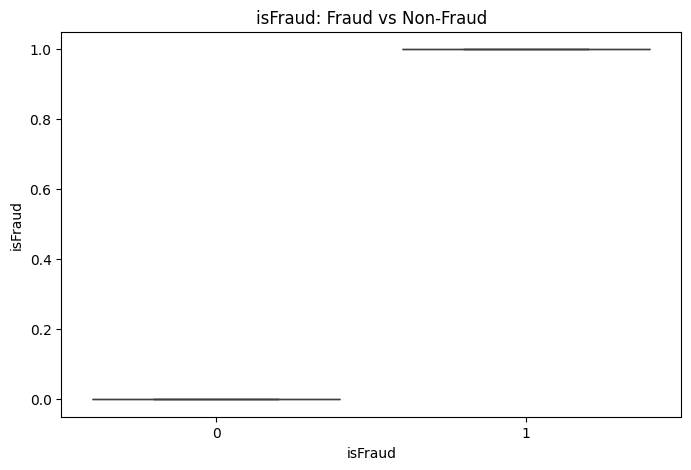

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y=feature
)

plt.title(f"{feature}: Fraud vs Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel(feature)

plt.show()

In [71]:
df.groupby("isFraud")[feature].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20663.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [72]:
top_features = fraud_corr.abs().sort_values(ascending=False).head(10)

print(top_features)


isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
dtype: float64


In [73]:
df.groupby("isFraud")[feature].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20663.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [74]:
top_features = fraud_corr.abs().sort_values(ascending=False).head(10)
print(top_features)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
dtype: float64


In [75]:
print(df["TransactionDT"].describe())

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64


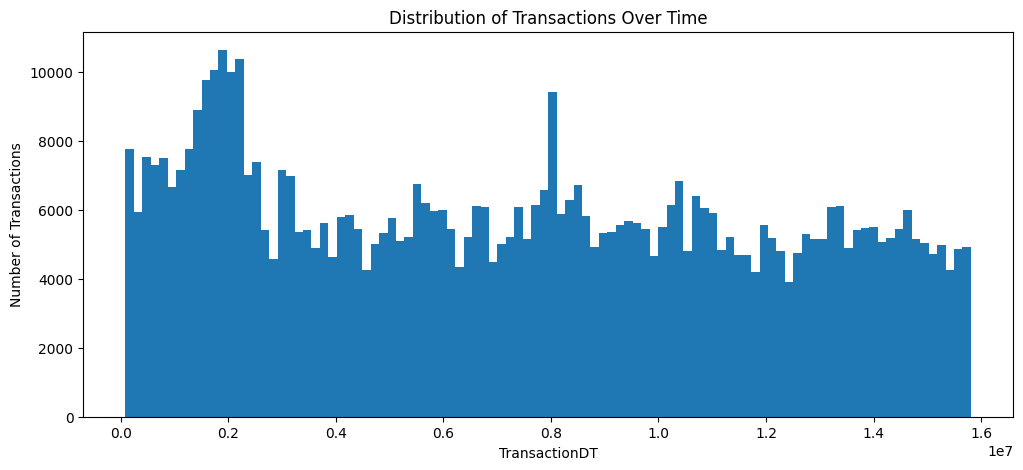

In [76]:
plt.figure(figsize=(12, 5))

plt.hist(
    df["TransactionDT"].dropna(),
    bins=100
)

plt.xlabel("TransactionDT")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transactions Over Time")

plt.show()

In [77]:
df["TimeBin"] = pd.qcut(
    df["TransactionDT"],
    q=20,
    duplicates="drop"
)

fraud_over_time = (
    df.groupby("TimeBin", observed=False)["isFraud"]
      .mean() * 100
)

print(fraud_over_time)

TimeBin
(86399.999, 751946.5]        2.878721
(751946.5, 1361004.4]        2.645037
(1361004.4, 1871911.2]       2.367325
(1871911.2, 2310159.6]       1.679818
(2310159.6, 3027057.75]      3.596708
(3027057.75, 3864163.9]      3.854100
(3864163.9, 4748458.85]      4.141972
(4748458.85, 5592303.6]      4.433231
(5592303.6, 6443299.15]      4.348562
(6443299.15, 7306527.5]      3.562841
(7306527.5, 8022309.6]       3.749111
(8022309.6, 8745782.4]       3.342703
(8745782.4, 9614666.75]      3.854100
(9614666.75, 10437998.1]     4.782064
(10437998.1, 11246620.0]     3.471399
(11246620.0, 12192853.6]     3.508653
(12192853.6, 13151846.0]     3.322383
(13151846.0, 13990907.7]     2.946456
(13990907.7, 14857872.15]    3.535747
(14857872.15, 15811131.0]    3.959088
Name: isFraud, dtype: float64


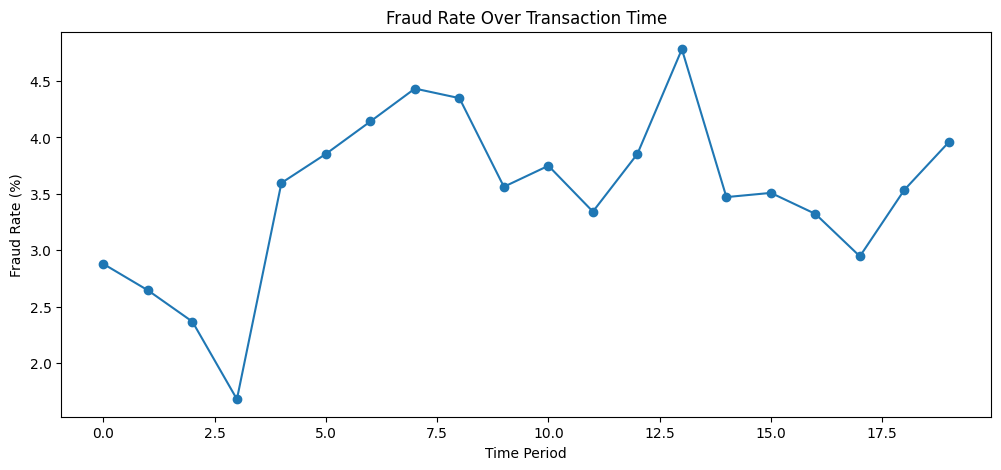

In [78]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(fraud_over_time)),
    fraud_over_time.values,
    marker="o"
)

plt.xlabel("Time Period")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Over Transaction Time")

plt.show()

In [79]:
sample_df = df.sample(n=100000, random_state=42)

fraud_corr = sample_df[numeric_cols].corrwith(
    sample_df["isFraud"]
)

fraud_corr = fraud_corr.sort_values(
    key=abs,
    ascending=False
)

print(fraud_corr.head(20))

isFraud    1.000000
V257       0.365644
V246       0.346830
V244       0.344396
V242       0.341745
V201       0.312907
V200       0.300456
V258       0.296730
V189       0.295821
V158       0.294606
V156       0.289826
V188       0.284976
V149       0.284951
V45        0.274864
V147       0.260213
V228       0.252162
V44        0.249859
V52        0.245046
V87        0.244962
V86        0.244412
dtype: float64


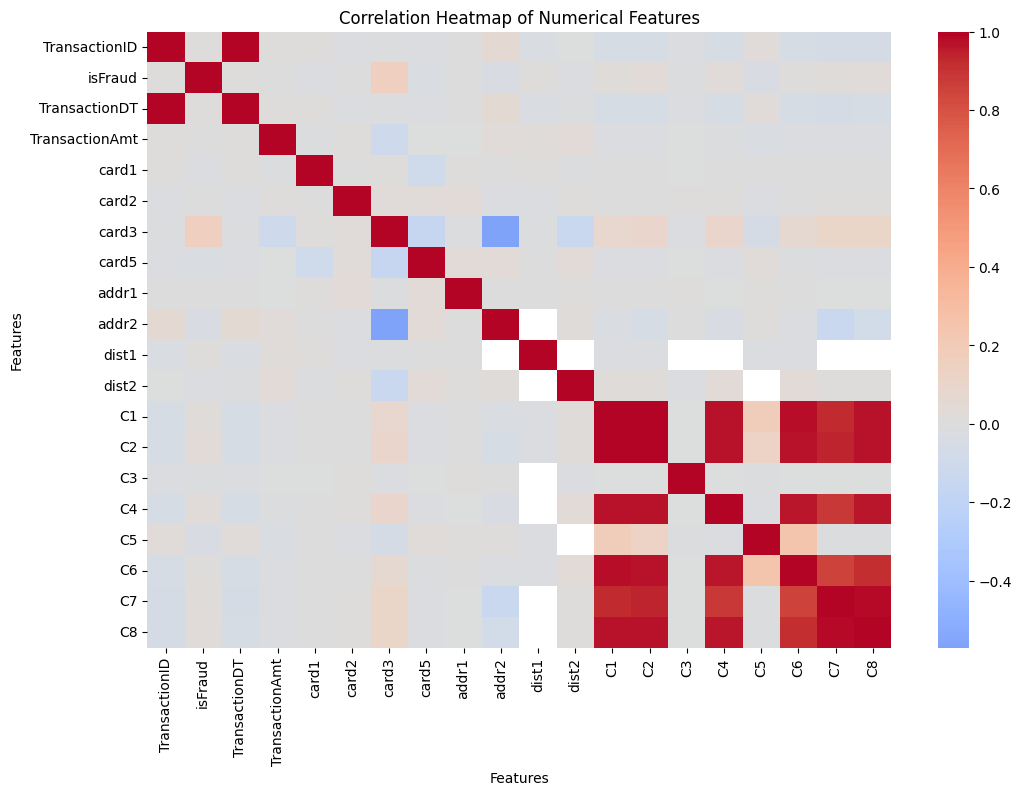

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Take a sample for faster EDA
sample_df = df.sample(n=100000, random_state=42)

# Select numerical columns
numeric_cols = sample_df.select_dtypes(
    include=["int64", "float64"]
).columns

# Take only the first 20 numerical features
# to keep the heatmap readable
corr_matrix = sample_df[numeric_cols[:20]].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

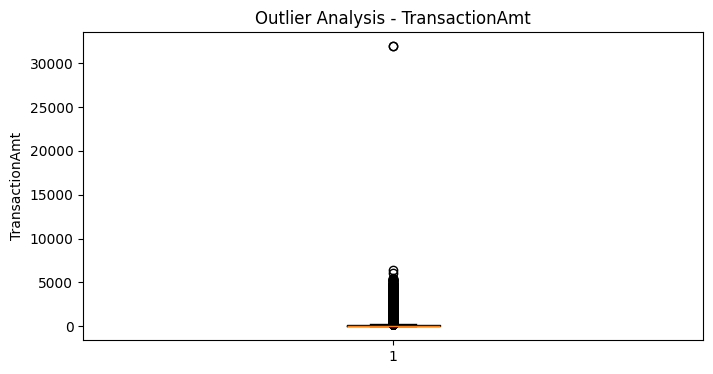

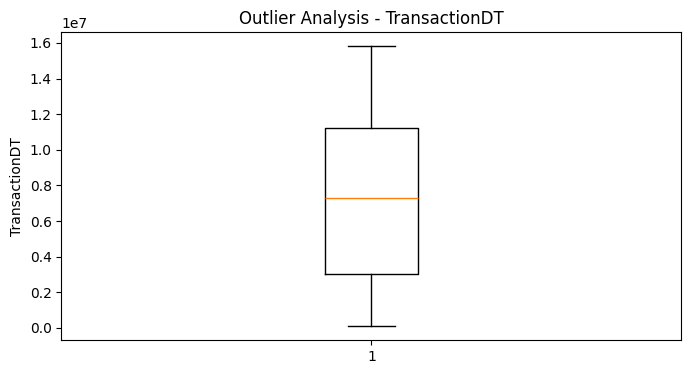

In [81]:
important_features = [
    "TransactionAmt",
    "TransactionDT"
]

for feature in important_features:
    if feature in df.columns:
        plt.figure(figsize=(8, 4))
        plt.boxplot(df[feature].dropna())
        plt.title(f"Outlier Analysis - {feature}")
        plt.ylabel(feature)
        plt.show()

In [82]:
import pandas as pd
import numpy as np

In [83]:
TARGET = "isFraud"

In [84]:
print("Loaded shape:", df.shape)

Loaded shape: (590540, 436)


In [85]:
required_cols = ["TransactionDT", "TransactionID", TARGET]

In [86]:
missing_required = [
    c for c in required_cols
    if c not in df.columns
]

In [87]:
if missing_required:
    raise ValueError(
        f"Missing required columns: {missing_required}"
    )

In [88]:
df = (
    df.sort_values("TransactionDT")
      .reset_index(drop=True)
)

In [89]:
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()
val_df = df.iloc[split_idx:].copy()

print("\nTemporal split:")
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print(
    "\nTrain fraud rate:",
    train_df[TARGET].mean()
)

print(
    "Validation fraud rate:",
    val_df[TARGET].mean()
)


Temporal split:
Train shape: (472432, 436)
Validation shape: (118108, 436)

Train fraud rate: 0.03513521522674162
Validation fraud rate: 0.034409184813899145


In [90]:
nunique = train_df.nunique(dropna=False)

near_constant_cols = (
    nunique[nunique <= 1]
    .index
    .tolist()
)

near_constant_cols = [
    c for c in near_constant_cols
    if c not in [TARGET, "TransactionID"]
]

print(
    "\nNear-constant columns:",
    len(near_constant_cols)
)

train_df.drop(
    columns=near_constant_cols,
    inplace=True,
    errors="ignore"
)

val_df.drop(
    columns=near_constant_cols,
    inplace=True,
    errors="ignore"
)


Near-constant columns: 0


In [91]:
missing_frac = train_df.isna().mean()

very_sparse_cols = (
    missing_frac[missing_frac > 0.95]
    .index
    .tolist()
)

very_sparse_cols = [
    c for c in very_sparse_cols
    if c not in [TARGET, "TransactionID"]
]

print(
    "Very sparse columns (>95% missing):",
    len(very_sparse_cols)
)

Very sparse columns (>95% missing): 9


In [92]:
flag_candidates = [
    "id_02",
    "id_05",
    "id_06",
    "id_11",
    "DeviceInfo"
]

flag_candidates = [
    c for c in flag_candidates
    if c in train_df.columns
]

for col in flag_candidates:

    train_df[f"{col}_isna"] = (
        train_df[col]
        .isna()
        .astype(int)
    )

    val_df[f"{col}_isna"] = (
        val_df[col]
        .isna()
        .astype(int)
    )

print(
    "Missingness flags created:",
    flag_candidates
)

Missingness flags created: ['id_02', 'id_05', 'id_06', 'id_11', 'DeviceInfo']


In [93]:
if "TransactionAmt" in train_df.columns:

    train_df["TransactionAmt_log"] = np.log1p(
        train_df["TransactionAmt"]
    )

    val_df["TransactionAmt_log"] = np.log1p(
        val_df["TransactionAmt"]
    )

In [94]:
def fit_top_categories(series, top_n=15):
    return (
        series
        .value_counts(dropna=False)
        .head(top_n)
        .index
    )


def apply_top_categories(
    series,
    top_values,
    other_label="other"
):
    return series.where(
        series.isin(top_values),
        other_label
    )
if "P_emaildomain" in train_df.columns:

    p_top = fit_top_categories(
        train_df["P_emaildomain"],
        top_n=15
    )

    train_df["P_emaildomain_bin"] = (
        apply_top_categories(
            train_df["P_emaildomain"],
            p_top
        )
    )

    val_df["P_emaildomain_bin"] = (
        apply_top_categories(
            val_df["P_emaildomain"],
            p_top
        )
    )

In [95]:
if "R_emaildomain" in train_df.columns:

    r_top = fit_top_categories(
        train_df["R_emaildomain"],
        top_n=15
    )

    train_df["R_emaildomain_bin"] = (
        apply_top_categories(
            train_df["R_emaildomain"],
            r_top
        )
    )

    val_df["R_emaildomain_bin"] = (
        apply_top_categories(
            val_df["R_emaildomain"],
            r_top
        )
    )

In [96]:
if "DeviceInfo" in train_df.columns:

    device_top = fit_top_categories(
        train_df["DeviceInfo"],
        top_n=20
    )

    train_df["DeviceInfo_bin"] = (
        apply_top_categories(
            train_df["DeviceInfo"],
            device_top
        )
    )

    val_df["DeviceInfo_bin"] = (
        apply_top_categories(
            val_df["DeviceInfo"],
            device_top
        )
    )

In [97]:
uid_required = ["card1", "addr1", "D1"]

missing_uid_cols = [
    c for c in uid_required
    if c not in train_df.columns
]

if missing_uid_cols:
    raise ValueError(
        f"Cannot create UID. Missing columns: {missing_uid_cols}"
    )


def create_uid(data):

    data["uid"] = (
        data["card1"].astype(str)
        + "_"
        + data["addr1"].astype(str)
        + "_"
        + data["D1"].astype(str)
    )

    return data


train_df = create_uid(train_df)
val_df = create_uid(val_df)

print(
    "\nTrain unique UIDs:",
    train_df["uid"].nunique()
)

print(
    "Validation unique UIDs:",
    val_df["uid"].nunique()
)



Train unique UIDs: 201883
Validation unique UIDs: 65155


In [98]:
def create_time_features(data):

    data["TransactionDay"] = (
        data["TransactionDT"]
        // (24 * 60 * 60)
    )

    data["D1n"] = (
        data["TransactionDay"] - data["D1"]
    )

    data["Transaction_hour"] = (
        data["TransactionDT"] // 3600
    ) % 24

    data["Transaction_dayofweek"] = (
        data["TransactionDT"]
        // (3600 * 24)
    ) % 7

    return data


train_df = create_time_features(train_df)
val_df = create_time_features(val_df)



In [99]:
agg_cols = [
    "TransactionAmt",
    "D4",
    "D10",
    "D15",
    "C1",
    "C13"
]

agg_cols = [
    c for c in agg_cols
    if c in train_df.columns
]

for col in agg_cols:

    uid_mean = (
        train_df
        .groupby("uid")[col]
        .mean()
    )

    uid_std = (
        train_df
        .groupby("uid")[col]
        .std()
    )

    # Apply train statistics to TRAIN
    train_df[f"{col}_uid_mean"] = (
        train_df["uid"].map(uid_mean)
    )

    train_df[f"{col}_uid_std"] = (
        train_df["uid"].map(uid_std)
    )

    # Apply the SAME train statistics to VALIDATION
    val_df[f"{col}_uid_mean"] = (
        val_df["uid"].map(uid_mean)
    )

    val_df[f"{col}_uid_std"] = (
        val_df["uid"].map(uid_std)
    )
uid_count_map = (
    train_df["uid"]
    .value_counts()
)

train_df["uid_count"] = (
    train_df["uid"]
    .map(uid_count_map)
)

val_df["uid_count"] = (
    val_df["uid"]
    .map(uid_count_map)
)

# UIDs never seen in training
# receive 0 in validation.
train_df["uid_count"] = (
    train_df["uid_count"]
    .fillna(0)
)

val_df["uid_count"] = (
    val_df["uid_count"]
    .fillna(0)
)



In [100]:
freq_encode_cols = [
    "card1",
    "card2",
    "addr1",
    "P_emaildomain",
    "DeviceInfo"
]

freq_encode_cols = [
    c for c in freq_encode_cols
    if c in train_df.columns
]

for col in freq_encode_cols:

    freq_map = (
        train_df[col]
        .value_counts(normalize=True)
    )

    train_df[f"{col}_freq"] = (
        train_df[col]
        .map(freq_map)
        .fillna(0)
    )

    val_df[f"{col}_freq"] = (
        val_df[col]
        .map(freq_map)
        .fillna(0)
    )



In [101]:
v_cols = [
    c for c in train_df.columns
    if c.startswith("V")
    and c[1:].isdigit()
]


def select_v_representatives(
    data,
    v_cols,
    target
):
    """
    Group V-columns by rounded missingness rate.
    Within each group, keep the V-column with the
    highest absolute correlation with the target.

    NOTE:
    This uses missingness RATE, not an exact row-by-row
    missingness pattern.
    """

    if not v_cols:
        return []

    missing_rate = (
        data[v_cols]
        .isna()
        .mean()
        .round(4)
    )

    groups = {}

    for col, rate in missing_rate.items():
        groups.setdefault(rate, []).append(col)

    representatives = []

    for rate, cols in groups.items():

        if len(cols) == 1:

            representatives.append(
                cols[0]
            )

        else:

            correlations = (
                data[cols]
                .corrwith(data[target])
                .abs()
            )

            correlations = correlations.dropna()

            if len(correlations) == 0:

                # If correlation cannot be calculated,
                # keep the first column as a fallback.
                representatives.append(cols[0])

            else:

                representatives.append(
                    correlations.idxmax()
                )

    return representatives


v_representatives = (
    select_v_representatives(
        train_df,
        v_cols,
        TARGET
    )
)

print(
    "\nKeeping",
    len(v_representatives),
    "representative V-columns out of",
    len(v_cols)
)



Keeping 14 representative V-columns out of 339


In [102]:
v_cols_to_drop = [
    c for c in v_cols
    if c not in v_representatives
]

drop_cols = list(
    dict.fromkeys(
        very_sparse_cols
        + v_cols_to_drop
    )
)

drop_cols = [
    c for c in drop_cols
    if c not in [TARGET, "TransactionID"]
]

train_df.drop(
    columns=[
        c for c in drop_cols
        if c in train_df.columns
    ],
    inplace=True,
    errors="ignore"
)

val_df.drop(
    columns=[
        c for c in drop_cols
        if c in val_df.columns
    ],
    inplace=True,
    errors="ignore"
)

print(
    "Columns marked for removal:",
    len(drop_cols)
)



Columns marked for removal: 334


In [103]:
keep_as_is = [
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "D1",
    "D4",
    "D10",
    "D15",
    "DeviceType"
]

keep_as_is += [
    c for c in train_df.columns
    if c.startswith("C")
    and c[1:].isdigit()
]

keep_as_is += [
    c for c in train_df.columns
    if c.startswith("M")
    and c[1:].isdigit()
]

keep_as_is = list(
    dict.fromkeys(
        c for c in keep_as_is
        if c in train_df.columns
    )
)

print(
    "Original features kept:",
    len(keep_as_is)
)



Original features kept: 37


In [104]:
engineered_features = [
    "uid",
    "D1n",
    "uid_count",
    "Transaction_hour",
    "Transaction_dayofweek",
    "TransactionAmt_log",
    "P_emaildomain_bin",
    "R_emaildomain_bin",
    "DeviceInfo_bin"
]

# UID aggregations
for col in agg_cols:

    engineered_features.append(
        f"{col}_uid_mean"
    )

    engineered_features.append(
        f"{col}_uid_std"
    )

# Frequency features
for col in freq_encode_cols:

    engineered_features.append(
        f"{col}_freq"
    )

# Missingness flags
for col in flag_candidates:

    engineered_features.append(
        f"{col}_isna"
    )

engineered_features = list(
    dict.fromkeys(
        c for c in engineered_features
        if c in train_df.columns
    )
)

print(
    "Engineered features:",
    len(engineered_features)
)


Engineered features: 31


In [105]:
ategorical_cols = (
    train_df
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

categorical_cols = [
    c for c in categorical_cols
    if c in (
        keep_as_is
        + engineered_features
    )
]

for col in categorical_cols:

    # Categories are learned from TRAIN only.
    train_categories = (
        train_df[col]
        .dropna()
        .unique()
    )

    train_df[col] = pd.Categorical(
        train_df[col],
        categories=train_categories
    )

    val_df[col] = pd.Categorical(
        val_df[col],
        categories=train_categories
    )

    train_df[col] = (
        train_df[col]
        .cat.codes
        .replace(-1, np.nan)
    )

    val_df[col] = (
        val_df[col]
        .cat.codes
        .replace(-1, np.nan)
    )

print(
    "Categorical columns encoded:",
    len(categorical_cols)
)



Categorical columns encoded: 13


In [106]:
final_features = list(
    dict.fromkeys(
        keep_as_is
        + v_representatives
        + engineered_features
    )
)

final_features = [
    c for c in final_features
    if c in train_df.columns
]

final_columns = [
    "TransactionID",
    TARGET
] + final_features


final_train = (
    train_df[final_columns]
    .copy()
)

final_val = (
    val_df[final_columns]
    .copy()
)



In [107]:
print("\n" + "=" * 60)
print("FINAL FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(
    "Final TRAIN shape:",
    final_train.shape
)

print(
    "Final VALIDATION shape:",
    final_val.shape
)

print(
    "Number of model features:",
    len(final_features)
)

print(
    "Train fraud rate:",
    final_train[TARGET].mean()
)

print(
    "Validation fraud rate:",
    final_val[TARGET].mean()
)

print(
    "Missing values in TRAIN:",
    final_train.isna().sum().sum()
)

print(
    "Missing values in VALIDATION:",
    final_val.isna().sum().sum()
)




FINAL FEATURE ENGINEERING SUMMARY
Final TRAIN shape: (472432, 84)
Final VALIDATION shape: (118108, 84)
Number of model features: 82
Train fraud rate: 0.03513521522674162
Validation fraud rate: 0.034409184813899145
Missing values in TRAIN: 7730447
Missing values in VALIDATION: 2190426


In [108]:
final_train.to_csv(
    "engineered_train.csv",
    index=False
)

final_val.to_csv(
    "engineered_validation.csv",
    index=False
)

print("\nSaved successfully:")
print("  -> engineered_train.csv")
print("  -> engineered_validation.csv")



Saved successfully:
  -> engineered_train.csv
  -> engineered_validation.csv


In [109]:
check = (
    train_df
    .groupby(
        pd.cut(
            train_df["uid_count"],
            bins=[0, 1, 2, 5, 10, 1000],
            include_lowest=True
        ),
        observed=False
    )[TARGET]
    .mean()
)

print(
    "\nFraud rate by uid_count bucket "
    "(TRAIN sanity check):"
)

print(check)

print("\nFeature engineering completed.")



Fraud rate by uid_count bucket (TRAIN sanity check):
uid_count
(-0.001, 1.0]     0.017679
(1.0, 2.0]        0.032230
(2.0, 5.0]        0.041219
(5.0, 10.0]       0.044098
(10.0, 1000.0]    0.045524
Name: isFraud, dtype: float64

Feature engineering completed.


In [110]:
train = pd.read_csv("engineered_train.csv")
val = pd.read_csv("engineered_validation.csv")

print("=" * 70)
print("FEATURE AUDIT STARTED")
print("=" * 70)

print("\nTrain shape:", train.shape)
print("Validation shape:", val.shape)


FEATURE AUDIT STARTED

Train shape: (472432, 84)
Validation shape: (118108, 84)


In [111]:
required_columns = [
    "TransactionID",
    "isFraud"
]

print("\n" + "=" * 70)
print("2. REQUIRED COLUMN CHECK")
print("=" * 70)

for col in required_columns:

    train_status = "PRESENT" if col in train.columns else "MISSING"
    val_status = "PRESENT" if col in val.columns else "MISSING"

    print(
        f"{col}: "
        f"Train = {train_status}, "
        f"Validation = {val_status}"
    )



2. REQUIRED COLUMN CHECK
TransactionID: Train = PRESENT, Validation = PRESENT
isFraud: Train = PRESENT, Validation = PRESENT


In [112]:
print("\n" + "=" * 70)
print("3. TRAIN / VALIDATION FEATURE CONSISTENCY")
print("=" * 70)

train_features = (
    set(train.columns)
    - {"TransactionID", "isFraud"}
)

val_features = (
    set(val.columns)
    - {"TransactionID", "isFraud"}
)

train_only = sorted(train_features - val_features)
val_only = sorted(val_features - train_features)

print("\nFeatures present only in TRAIN:")
print(train_only if train_only else "None")

print("\nFeatures present only in VALIDATION:")
print(val_only if val_only else "None")

if not train_only and not val_only:
    print("\nRESULT: PASS - Train and validation have the same model features.")
else:
    print("\nRESULT: WARNING - Feature mismatch detected.")



3. TRAIN / VALIDATION FEATURE CONSISTENCY

Features present only in TRAIN:
None

Features present only in VALIDATION:
None

RESULT: PASS - Train and validation have the same model features.


In [113]:
print("\n" + "=" * 70)
print("4. TARGET CHECK")
print("=" * 70)

print("Target present in train:",
      "isFraud" in train.columns)

print("Target present in validation:",
      "isFraud" in val.columns)

if "isFraud" in train.columns:

    print("\nTrain target distribution:")
    print(train["isFraud"].value_counts())

    print("\nTrain target percentage:")
    print(train["isFraud"].value_counts(normalize=True))

if "isFraud" in val.columns:

    print("\nValidation target distribution:")
    print(val["isFraud"].value_counts())

    print("\nValidation target percentage:")
    print(val["isFraud"].value_counts(normalize=True))




4. TARGET CHECK
Target present in train: True
Target present in validation: True

Train target distribution:
isFraud
0    455833
1     16599
Name: count, dtype: int64

Train target percentage:
isFraud
0    0.964865
1    0.035135
Name: proportion, dtype: float64

Validation target distribution:
isFraud
0    114044
1      4064
Name: count, dtype: int64

Validation target percentage:
isFraud
0    0.965591
1    0.034409
Name: proportion, dtype: float64


In [114]:
print("\n" + "=" * 70)
print("5. TARGET LEAKAGE CHECK")
print("=" * 70)

feature_cols = [
    c for c in train.columns
    if c not in ["TransactionID", "isFraud"]
]

target_in_features = "isFraud" in feature_cols

print(
    "Is isFraud included in model features?",
    target_in_features
)

if not target_in_features:
    print("RESULT: PASS")
else:
    print("RESULT: WARNING - Target leakage detected.")




5. TARGET LEAKAGE CHECK
Is isFraud included in model features? False
RESULT: PASS


In [115]:
print("\n" + "=" * 70)
print("6. IMPORTANT ENGINEERED FEATURE CHECK")
print("=" * 70)

important_features = [

    # UID
    "uid",
    "uid_count",
    "D1n",

    # Transaction
    "TransactionAmt_log",

    # Time
    "Transaction_hour",
    "Transaction_dayofweek",

    # Email / device
    "P_emaildomain_bin",
    "R_emaildomain_bin",
    "DeviceInfo_bin",

    # Frequency
    "card1_freq",
    "card2_freq",
    "addr1_freq",
    "P_emaildomain_freq",
    "DeviceInfo_freq",

    # Missingness
    "id_02_isna",
    "id_05_isna",
    "id_06_isna",
    "id_11_isna",
    "DeviceInfo_isna",
]

missing_important = []
present_important = []

for col in important_features:

    if col in train.columns:
        print(f"PASS  - {col}")
        present_important.append(col)
    else:
        print(f"MISS  - {col}")
        missing_important.append(col)

print(
    "\nImportant features present:",
    len(present_important),
    "/",
    len(important_features)
)

if missing_important:
    print("\nImportant features missing:")
    print(missing_important)
else:
    print("\nRESULT: PASS - All listed important engineered features exist.")



6. IMPORTANT ENGINEERED FEATURE CHECK
PASS  - uid
PASS  - uid_count
PASS  - D1n
PASS  - TransactionAmt_log
PASS  - Transaction_hour
PASS  - Transaction_dayofweek
PASS  - P_emaildomain_bin
PASS  - R_emaildomain_bin
PASS  - DeviceInfo_bin
PASS  - card1_freq
PASS  - card2_freq
PASS  - addr1_freq
PASS  - P_emaildomain_freq
PASS  - DeviceInfo_freq
PASS  - id_02_isna
PASS  - id_05_isna
PASS  - id_06_isna
PASS  - id_11_isna
PASS  - DeviceInfo_isna

Important features present: 19 / 19

RESULT: PASS - All listed important engineered features exist.


In [116]:
print("\n" + "=" * 70)
print("7. UID AGGREGATION FEATURE CHECK")
print("=" * 70)

uid_agg_features = [
    c for c in train.columns
    if "_uid_mean" in c
    or "_uid_std" in c
]

print(
    "Number of UID aggregation features:",
    len(uid_agg_features)
)

if uid_agg_features:
    print("\nUID aggregation features:")
    for col in uid_agg_features:
        print(" -", col)
else:
    print("WARNING - No UID aggregation features found.")



7. UID AGGREGATION FEATURE CHECK
Number of UID aggregation features: 12

UID aggregation features:
 - TransactionAmt_uid_mean
 - TransactionAmt_uid_std
 - D4_uid_mean
 - D4_uid_std
 - D10_uid_mean
 - D10_uid_std
 - D15_uid_mean
 - D15_uid_std
 - C1_uid_mean
 - C1_uid_std
 - C13_uid_mean
 - C13_uid_std


In [117]:
print("\n" + "=" * 70)
print("8. FREQUENCY FEATURE CHECK")
print("=" * 70)

frequency_features = [
    c for c in train.columns
    if c.endswith("_freq")
]

print(
    "Number of frequency features:",
    len(frequency_features)
)

if frequency_features:
    for col in frequency_features:
        print(" -", col)
else:
    print("WARNING - No frequency features found.")




8. FREQUENCY FEATURE CHECK
Number of frequency features: 5
 - card1_freq
 - card2_freq
 - addr1_freq
 - P_emaildomain_freq
 - DeviceInfo_freq


In [118]:
print("\n" + "=" * 70)
print("9. MISSINGNESS FLAG CHECK")
print("=" * 70)

missingness_features = [
    c for c in train.columns
    if c.endswith("_isna")
]

print(
    "Number of missingness flag features:",
    len(missingness_features)
)

if missingness_features:
    for col in missingness_features:
        print(" -", col)
else:
    print("WARNING - No missingness flag features found.")




9. MISSINGNESS FLAG CHECK
Number of missingness flag features: 5
 - id_02_isna
 - id_05_isna
 - id_06_isna
 - id_11_isna
 - DeviceInfo_isna


In [119]:
print("\n" + "=" * 70)
print("10. MISSING VALUE CHECK")
print("=" * 70)

train_missing = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
)

train_missing = train_missing[
    train_missing > 0
]

val_missing = (
    val.isna()
    .sum()
    .sort_values(ascending=False)
)

val_missing = val_missing[
    val_missing > 0
]

print("\nTRAIN features with missing values:")

if len(train_missing) > 0:
    print(train_missing.head(30))
else:
    print("None")

print("\nVALIDATION features with missing values:")

if len(val_missing) > 0:
    print(val_missing.head(30))
else:
    print("None")





10. MISSING VALUE CHECK

TRAIN features with missing values:
V158                      402728
V324                      402411
DeviceInfo_bin            372896
V257                      362497
R_emaildomain_bin         358812
V177                      355933
V201                      355767
DeviceType                354794
V222                      354412
M7                        299980
M8                        299974
M9                        299974
M5                        283514
V10                       245973
M3                        238295
M2                        238295
M1                        238295
M4                        227191
D4_uid_std                187055
D15_uid_std               166545
D10_uid_std               163706
TransactionAmt_uid_std    149105
C13_uid_std               149105
C1_uid_std                149105
M6                        141415
V45                       139809
D4                        139774
V87                        77793
D15           

In [120]:
print("\n" + "=" * 70)
print("11. DUPLICATE COLUMN CHECK")
print("=" * 70)

duplicate_train = train.columns[
    train.columns.duplicated()
].tolist()

duplicate_val = val.columns[
    val.columns.duplicated()
].tolist()

print("Duplicate columns in TRAIN:")
print(duplicate_train if duplicate_train else "None")

print("\nDuplicate columns in VALIDATION:")
print(duplicate_val if duplicate_val else "None")




11. DUPLICATE COLUMN CHECK
Duplicate columns in TRAIN:
None

Duplicate columns in VALIDATION:
None


In [121]:
print("\n" + "=" * 70)
print("12. INFINITE VALUE CHECK")
print("=" * 70)

train_numeric = train.select_dtypes(
    include=np.number
)

val_numeric = val.select_dtypes(
    include=np.number
)

train_inf = np.isinf(
    train_numeric
).sum().sum()

val_inf = np.isinf(
    val_numeric
).sum().sum()

print("Infinite values in TRAIN:",
      train_inf)

print("Infinite values in VALIDATION:",
      val_inf)

if train_inf == 0 and val_inf == 0:
    print("RESULT: PASS")
else:
    print("RESULT: WARNING - Infinite values detected.")



12. INFINITE VALUE CHECK
Infinite values in TRAIN: 0
Infinite values in VALIDATION: 0
RESULT: PASS


In [122]:
print("\n" + "=" * 70)
print("13. FINAL FEATURE COUNT")
print("=" * 70)

feature_cols = [
    c for c in train.columns
    if c not in ["TransactionID", "isFraud"]
]

print(
    "Total model features:",
    len(feature_cols)
)

print(
    "Total train columns:",
    len(train.columns)
)

print(
    "Total validation columns:",
    len(val.columns)
)

print(
    "\nExpected relationship:"
)

print(
    len(feature_cols),
    "+ TransactionID"
    "+ isFraud =",
    len(feature_cols) + 2
)





13. FINAL FEATURE COUNT
Total model features: 82
Total train columns: 84
Total validation columns: 84

Expected relationship:
82 + TransactionID+ isFraud = 84


In [123]:
print("\n" + "=" * 70)
print("14. TRAIN / VALIDATION DATA TYPE CHECK")
print("=" * 70)

dtype_difference = []

common_features = sorted(
    train_features & val_features
)

for col in common_features:

    if train[col].dtype != val[col].dtype:

        dtype_difference.append(
            (
                col,
                str(train[col].dtype),
                str(val[col].dtype)
            )
        )

if dtype_difference:

    print("WARNING - Data type differences found:")

    for item in dtype_difference:
        print(item)

else:

    print(
        "RESULT: PASS - All common model features "
        "have matching data types."
    )





14. TRAIN / VALIDATION DATA TYPE CHECK
WARNING - Data type differences found:
('uid_count', 'int64', 'float64')


In [124]:
print("\n" + "=" * 70)
print("15. TEMPORAL ORDER CHECK")
print("=" * 70)

# TransactionDT is not necessarily present in the final table
# because the final feature list may exclude it.
# Therefore, this check is performed only if available.

if "TransactionDT" in train.columns and "TransactionDT" in val.columns:

    train_max = train["TransactionDT"].max()
    val_min = val["TransactionDT"].min()

    print("Maximum TRAIN TransactionDT:",
          train_max)

    print("Minimum VALIDATION TransactionDT:",
          val_min)

    if train_max <= val_min:
        print(
            "RESULT: PASS - Validation contains later transactions."
        )
    else:
        print(
            "RESULT: WARNING - Temporal overlap detected."
        )

else:

    print(
        "TransactionDT is not in the finalized files; "
        "temporal split was performed before feature assembly."
    )



15. TEMPORAL ORDER CHECK
TransactionDT is not in the finalized files; temporal split was performed before feature assembly.


In [125]:
print("\n" + "=" * 70)
print("FINAL FEATURE AUDIT SUMMARY")
print("=" * 70)

checks = {}

checks["Train/Validation feature match"] = (
    len(train_only) == 0
    and len(val_only) == 0
)

checks["Target available"] = (
    "isFraud" in train.columns
    and "isFraud" in val.columns
)

checks["No target in model features"] = (
    not target_in_features
)

checks["Important engineered features"] = (
    len(missing_important) == 0
)

checks["UID aggregation features"] = (
    len(uid_agg_features) > 0
)

checks["Frequency features"] = (
    len(frequency_features) > 0
)

checks["Missingness features"] = (
    len(missingness_features) > 0
)

checks["No duplicate columns"] = (
    len(duplicate_train) == 0
    and len(duplicate_val) == 0
)

checks["No infinite values"] = (
    train_inf == 0
    and val_inf == 0
)

checks["Matching data types"] = (
    len(dtype_difference) == 0
)

for name, result in checks.items():

    print(
        f"{'PASS' if result else 'CHECK'}  - {name}"
    )

print("\n" + "=" * 70)
print("AUDIT COMPLETE")
print("=" * 70)

print(
    """
Interpretation:

PASS  = The check passed.
CHECK = Review that item before model training.

Do not automatically modify the datasets based only on a CHECK.
Review the output first, especially missing important features
or feature mismatches.
"""
)



FINAL FEATURE AUDIT SUMMARY
PASS  - Train/Validation feature match
PASS  - Target available
PASS  - No target in model features
PASS  - Important engineered features
PASS  - UID aggregation features
PASS  - Frequency features
PASS  - Missingness features
PASS  - No duplicate columns
PASS  - No infinite values
CHECK  - Matching data types

AUDIT COMPLETE

Interpretation:

PASS  = The check passed.
CHECK = Review that item before model training.

Do not automatically modify the datasets based only on a CHECK.
Review the output first, especially missing important features
or feature mismatches.



In [126]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this directory:")
print(os.listdir())

Current working directory:
C:\Users\madhu\OneDrive\Desktop\cts

Files in this directory:
['.ipynb_checkpoints', 'engineered_train.csv', 'engineered_validation.csv', 'feature_engineering.ipynb', 'merged_dataset.csv', 'sample_submission.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']


In [127]:
import pandas as pd
import numpy as np

# Load the engineered datasets
train_df = pd.read_csv("engineered_train.csv")
val_df = pd.read_csv("engineered_validation.csv")

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTraining columns:", len(train_df.columns))
print("Validation columns:", len(val_df.columns))

Training shape: (472432, 84)
Validation shape: (118108, 84)

Training columns: 84
Validation columns: 84


In [128]:
print("Target distribution in training:")
print(train_df["isFraud"].value_counts())

print("\nTarget distribution in validation:")
print(val_df["isFraud"].value_counts())

print("\nFraud percentage in training:")
print(train_df["isFraud"].mean() * 100)

print("\nFraud percentage in validation:")
print(val_df["isFraud"].mean() * 100)

Target distribution in training:
isFraud
0    455833
1     16599
Name: count, dtype: int64

Target distribution in validation:
isFraud
0    114044
1      4064
Name: count, dtype: int64

Fraud percentage in training:
3.5135215226741625

Fraud percentage in validation:
3.4409184813899145


In [129]:
train_features = set(train_df.columns) - {"isFraud"}
val_features = set(val_df.columns) - {"isFraud"}

print("Features only in training:")
print(train_features - val_features)

print("\nFeatures only in validation:")
print(val_features - train_features)

print("\nNumber of common features:", len(train_features & val_features))

Features only in training:
set()

Features only in validation:
set()

Number of common features: 83


In [130]:
print("===== DATA TYPES =====")
print(train_df.dtypes.value_counts())

print("\n===== MISSING VALUES =====")
missing = train_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values found.")
else:
    print(missing.head(20))

print("\n===== DUPLICATE ROWS =====")
print("Training duplicates:", train_df.duplicated().sum())
print("Validation duplicates:", val_df.duplicated().sum())

print("\n===== TARGET =====")
print(train_df["isFraud"].value_counts())

===== DATA TYPES =====
float64    68
int64      12
object      4
Name: count, dtype: int64

===== MISSING VALUES =====
V158                 402728
V324                 402411
DeviceInfo_bin       372896
V257                 362497
R_emaildomain_bin    358812
V177                 355933
V201                 355767
DeviceType           354794
V222                 354412
M7                   299980
M9                   299974
M8                   299974
M5                   283514
V10                  245973
M3                   238295
M1                   238295
M2                   238295
M4                   227191
D4_uid_std           187055
D15_uid_std          166545
dtype: int64

===== DUPLICATE ROWS =====
Training duplicates: 0
Validation duplicates: 0

===== TARGET =====
isFraud
0    455833
1     16599
Name: count, dtype: int64


In [131]:
import pandas as pd
import numpy as np

# Load the feature-engineered datasets
train_df = pd.read_csv("engineered_train.csv")
val_df = pd.read_csv("engineered_validation.csv")

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTraining target distribution:")
print(train_df["isFraud"].value_counts())

print("\nValidation target distribution:")
print(val_df["isFraud"].value_counts())

Training shape: (472432, 84)
Validation shape: (118108, 84)

Training target distribution:
isFraud
0    455833
1     16599
Name: count, dtype: int64

Validation target distribution:
isFraud
0    114044
1      4064
Name: count, dtype: int64


In [132]:
TARGET = "isFraud"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (472432, 83)
y_train: (472432,)
X_val: (118108, 83)
y_val: (118108,)


In [133]:
print("===== CLASS DISTRIBUTION =====")

print("\nTraining:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

fraud_count = (y_train == 1).sum()
nonfraud_count = (y_train == 0).sum()

scale_pos_weight = nonfraud_count / fraud_count

print("\nFraud rate:", y_train.mean())
print("Scale pos weight:", scale_pos_weight)

===== CLASS DISTRIBUTION =====

Training:
isFraud
0    455833
1     16599
Name: count, dtype: int64

Validation:
isFraud
0    114044
1      4064
Name: count, dtype: int64

Fraud rate: 0.03513521522674162
Scale pos weight: 27.46147358274595


In [134]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

Categorical columns:
['uid', 'P_emaildomain_bin', 'R_emaildomain_bin', 'DeviceInfo_bin']

Number of categorical columns: 4


In [ ]:
#Identifying Categorical Features

LightGBM can handle categorical variables directly without one-hot encoding. We therefore identify the categorical columns in the training data so they can be converted to the appropriate category dtype.

In [135]:
# Make copies so we don't accidentally modify the original data
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()

# Convert categorical columns to pandas category dtype
for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_val_lgb[col] = X_val_lgb[col].astype("category")

print("Categorical columns prepared:")
for col in categorical_cols:
    print(f"{col}: {X_train_lgb[col].dtype}")

Categorical columns prepared:
uid: category
P_emaildomain_bin: category
R_emaildomain_bin: category
DeviceInfo_bin: category


In [ ]:
#Preparing Data for LightGBM

Copies of the training and validation datasets are created to avoid modifying the original feature matrices. The identified categorical features are converted to pandas category dtype so that LightGBM can process them natively


In [175]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [136]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


In [137]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("engineered_train.csv")
val_df = pd.read_csv("engineered_validation.csv")

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Training shape: (472432, 84)
Validation shape: (118108, 84)


In [139]:
# Make categorical columns explicitly categorical for LightGBM

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")

print("Categorical columns prepared:")

for col in categorical_cols:
    print(f"{col}: {X_train[col].dtype}")

Categorical columns prepared:
uid: category
P_emaildomain_bin: category
R_emaildomain_bin: category
DeviceInfo_bin: category


In [141]:
# Make sure train and validation categorical columns use
# exactly the same category definitions

for col in categorical_cols:
    X_val[col] = X_val[col].cat.set_categories(
        X_train[col].cat.categories
    )

print("Categorical columns aligned successfully.")

for col in categorical_cols:
    print(
        f"{col}: "
        f"train categories = {len(X_train[col].cat.categories)}, "
        f"validation categories = {len(X_val[col].cat.categories)}"
    )

Categorical columns aligned successfully.
uid: train categories = 201883, validation categories = 201883
P_emaildomain_bin: train categories = 15, validation categories = 15
R_emaildomain_bin: train categories = 15, validation categories = 15
DeviceInfo_bin: train categories = 20, validation categories = 20


In [ ]:
# Create Final Train, Validation, and Test Sets

Combine the previously prepared training and validation data and create the final experimental split.

15% of the complete labelled dataset is held out as an untouched test set. The remaining 85% is split into training and validation sets.

Stratified splitting is used to preserve the highly imbalanced fraud-to-legitimate transaction ratio across all datasets.
    

In [179]:
from sklearn.model_selection import train_test_split

# Reconstruct the complete labeled dataset
X_all = pd.concat([X_train, X_val], axis=0)
y_all = pd.concat([y_train, y_val], axis=0)

print("Full X:", X_all.shape)
print("Full y:", y_all.shape)

# --------------------------------------------------
# Step 1: Keep 15% completely aside as TEST
# --------------------------------------------------

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.15,
    stratify=y_all,
    random_state=42
)

# --------------------------------------------------
# Step 2: Split remaining 85% into TRAIN + VALIDATION
# --------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.17647,
    stratify=y_temp,
    random_state=42
)

print("\nNew splits:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nFraud rates:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Full X: (590540, 83)
Full y: (590540,)

New splits:
Train: (413378, 83)
Validation: (88581, 83)
Test: (88581, 83)

Fraud rates:
Train: 0.034989767234831076
Validation: 0.03499621815061921
Test: 0.03498492904798998


In [ ]:
#### Create Final Train, Validation, and Test Sets

Combine the previously prepared training and validation data and create the final experimental split.

15% of the complete labelled dataset is held out as an untouched test set. The remaining 85% is split into training and validation sets.

Stratified splitting is used to preserve the highly imbalanced fraud-to-legitimate transaction ratio across all datasets.

In [180]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("New scale_pos_weight:", scale_pos_weight)

New scale_pos_weight: 27.5797842920354


In [ ]:
### Calculate Class-Imbalance Weight

Calculate `scale_pos_weight` from the final training set to compensate for the severe class imbalance.

The weight is calculated as:

$$
scale\_pos\_weight =
\frac{\text{number of legitimate transactions}}
{\text{number of fraudulent transactions}}
$$

This gives fraudulent transactions greater influence during model training.

In [181]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=64,
    max_depth=-1,
    min_child_samples=50,

    scale_pos_weight=scale_pos_weight,

    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1,
    verbosity=-1,

    metric="None"
)

In [ ]:
### Define LightGBM Fraud Detection Model

Configure the LightGBM binary classification model using the selected hyperparameters.

The model uses class weighting to address the severe fraud-class imbalance, while feature and bagging fractions introduce additional randomness to help control overfitting.

The model is configured for binary fraud classification.
    

In [182]:
model.fit(
    X_train,
    y_train,

    categorical_feature=categorical_cols,

    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],

    eval_names=[
        "train",
        "validation"
    ],

    eval_metric=[
        "average_precision",
        "auc"
    ],

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        )
    ]
)

C:\Users\madhu\miniconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1999]	train's average_precision: 0.986893	train's auc: 0.999614	validation's average_precision: 0.80906	validation's auc: 0.954214


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [ ]:
### Train LightGBM Model

Train the LightGBM classifier on the final training set.

The validation set is supplied separately so that model performance can be monitored during boosting and the appropriate number of boosting iterations can be identified.

The categorical features are explicitly provided to LightGBM.
    

In [183]:
print("Best iteration:", model.best_iteration_)
print("Best score:", model.best_score_)
print("Number of trees:", model.booster_.num_trees())

Best iteration: 1999
Best score: defaultdict(<class 'collections.OrderedDict'>, {'train': OrderedDict({'average_precision': np.float64(0.9868928841373094), 'auc': np.float64(0.9996136348023656)}), 'validation': OrderedDict({'average_precision': np.float64(0.8090598955814148), 'auc': np.float64(0.9542135830222223)})})
Number of trees: 1999


In [189]:
# Validation probabilities from NEW model

y_val_prob = model.predict_proba(
    X_val,
    num_iteration=model.best_iteration_
)[:, 1]

print("Validation probabilities generated.")
print("Min probability:", y_val_prob.min())
print("Max probability:", y_val_prob.max())

Validation probabilities generated.
Min probability: 1.3689359868376125e-06
Max probability: 0.9999497865912772


In [190]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = np.arange(0.40, 0.61, 0.01)

print("Threshold | Precision | Recall | F1")
print("-" * 42)

for threshold in thresholds:
    y_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    print(
        f"{threshold:9.2f} | "
        f"{precision:10.4f} | "
        f"{recall:6.4f} | "
        f"{f1:6.4f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.40 |     0.5766 | 0.8232 | 0.6782
     0.41 |     0.5852 | 0.8216 | 0.6836
     0.42 |     0.5957 | 0.8184 | 0.6895
     0.43 |     0.6060 | 0.8171 | 0.6959
     0.44 |     0.6135 | 0.8142 | 0.6998
     0.45 |     0.6234 | 0.8116 | 0.7052
     0.46 |     0.6312 | 0.8084 | 0.7089
     0.47 |     0.6396 | 0.8077 | 0.7139
     0.48 |     0.6491 | 0.8048 | 0.7186
     0.49 |     0.6582 | 0.8019 | 0.7230
     0.50 |     0.6658 | 0.7987 | 0.7262
     0.51 |     0.6768 | 0.7965 | 0.7318
     0.52 |     0.6870 | 0.7945 | 0.7369
     0.53 |     0.6956 | 0.7916 | 0.7405
     0.54 |     0.7047 | 0.7897 | 0.7448
     0.55 |     0.7130 | 0.7861 | 0.7478
     0.56 |     0.7208 | 0.7835 | 0.7509
     0.57 |     0.7304 | 0.7813 | 0.7550
     0.58 |     0.7388 | 0.7800 | 0.7588
     0.59 |     0.7447 | 0.7765 | 0.7603
     0.60 |     0.7526 | 0.7703 | 0.7614


In [191]:
thresholds = np.arange(0.40, 0.61, 0.01)

# Cost assumptions
COST_FP = 500
COST_FN = 1200

print("Threshold | FP | FN | Precision | Recall | Total Cost")
print("-" * 65)

results = []

for threshold in thresholds:

    y_pred = (y_val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)

    total_cost = (fp * COST_FP) + (fn * COST_FN)

    results.append({
        "threshold": threshold,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "cost": total_cost
    })

    print(
        f"{threshold:9.2f} | "
        f"{fp:4d} | "
        f"{fn:4d} | "
        f"{precision:10.4f} | "
        f"{recall:6.4f} | "
        f"₹{total_cost:,}"
    )

Threshold | FP | FN | Precision | Recall | Total Cost
-----------------------------------------------------------------
     0.40 | 1874 |  548 |     0.5766 | 0.8232 | ₹1,594,600
     0.41 | 1805 |  553 |     0.5852 | 0.8216 | ₹1,566,100
     0.42 | 1722 |  563 |     0.5957 | 0.8184 | ₹1,536,600
     0.43 | 1647 |  567 |     0.6060 | 0.8171 | ₹1,503,900
     0.44 | 1590 |  576 |     0.6135 | 0.8142 | ₹1,486,200
     0.45 | 1520 |  584 |     0.6234 | 0.8116 | ₹1,460,800
     0.46 | 1464 |  594 |     0.6312 | 0.8084 | ₹1,444,800
     0.47 | 1411 |  596 |     0.6396 | 0.8077 | ₹1,420,700
     0.48 | 1349 |  605 |     0.6491 | 0.8048 | ₹1,400,500
     0.49 | 1291 |  614 |     0.6582 | 0.8019 | ₹1,382,300
     0.50 | 1243 |  624 |     0.6658 | 0.7987 | ₹1,370,300
     0.51 | 1179 |  631 |     0.6768 | 0.7965 | ₹1,346,700
     0.52 | 1122 |  637 |     0.6870 | 0.7945 | ₹1,325,400
     0.53 | 1074 |  646 |     0.6956 | 0.7916 | ₹1,312,200
     0.54 | 1026 |  652 |     0.7047 | 0.7897 | ₹1,295

In [192]:
thresholds_fine = np.arange(0.57, 0.601, 0.001)

best_cost = float("inf")
best_threshold = None
best_results = None

for threshold in thresholds_fine:

    y_pred = (y_val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    total_cost = (fp * COST_FP) + (fn * COST_FN)

    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = threshold
        best_results = {
            "threshold": threshold,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "cost": total_cost
        }

print("BEST THRESHOLD:", best_threshold)
print("FP:", best_results["fp"])
print("FN:", best_results["fn"])
print("TP:", best_results["tp"])
print("TN:", best_results["tn"])
print("Precision:", best_results["precision"])
print("Recall:", best_results["recall"])
print("F1:", best_results["f1"])
print("Total Cost: ₹", best_results["cost"])

BEST THRESHOLD: 0.587
FP: 831
FN: 689
TP: 2411
TN: 84650
Precision: 0.7436767427513881
Recall: 0.7777419354838709
F1: 0.760327972248502
Total Cost: ₹ 1242300


In [186]:
thresholds = np.arange(0.41, 0.451, 0.001)

FP_COST = 100
FN_COST = 1000

print("Threshold | FP | FN | Precision | Recall | Total Cost")
print("-" * 70)

for threshold in thresholds:

    y_pred = (y_val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    total_cost = (
        fp * FP_COST +
        fn * FN_COST
    )

    print(
        f"{threshold:9.2f} | "
        f"{fp:4d} | "
        f"{fn:4d} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"₹{total_cost:,}"
    )

Threshold | FP | FN | Precision | Recall | Total Cost
----------------------------------------------------------------------
     0.41 | 1805 |  553 |    0.5852 | 0.8216 | ₹733,500
     0.41 | 1800 |  554 |    0.5858 | 0.8213 | ₹734,000
     0.41 | 1785 |  554 |    0.5879 | 0.8213 | ₹732,500
     0.41 | 1780 |  554 |    0.5885 | 0.8213 | ₹732,000
     0.41 | 1776 |  557 |    0.5888 | 0.8203 | ₹734,600
     0.41 | 1762 |  558 |    0.5906 | 0.8200 | ₹734,200
     0.42 | 1756 |  558 |    0.5914 | 0.8200 | ₹733,600
     0.42 | 1748 |  559 |    0.5924 | 0.8197 | ₹733,800
     0.42 | 1740 |  561 |    0.5934 | 0.8190 | ₹735,000
     0.42 | 1729 |  562 |    0.5948 | 0.8187 | ₹734,900
     0.42 | 1722 |  563 |    0.5957 | 0.8184 | ₹735,200
     0.42 | 1712 |  564 |    0.5970 | 0.8181 | ₹735,200
     0.42 | 1704 |  565 |    0.5980 | 0.8177 | ₹735,400
     0.42 | 1696 |  565 |    0.5991 | 0.8177 | ₹734,600
     0.42 | 1690 |  565 |    0.6000 | 0.8177 | ₹734,000
     0.42 | 1678 |  565 |    0.6017

In [187]:
final_threshold = 0.435

y_val_pred = (y_val_prob >= final_threshold).astype(int)

tn = ((y_val == 0) & (y_val_pred == 0)).sum()
fp = ((y_val == 0) & (y_val_pred == 1)).sum()
fn = ((y_val == 1) & (y_val_pred == 0)).sum()
tp = ((y_val == 1) & (y_val_pred == 1)).sum()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

total_cost = (fp * 100) + (fn * 1000)

print("FINAL THRESHOLD:", final_threshold)

print("\nConfusion Matrix:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nFraud Detection:")
print("Actual fraud :", y_val.sum())
print("Fraud caught :", tp)
print("Fraud missed :", fn)

print("\nFlagged Transactions:")
print("Total flagged:", tp + fp)
print("Actually fraudulent among flagged:", tp)
print("False alarms:", fp)

print("\nMetrics:")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nTotal Cost: ₹", total_cost)

FINAL THRESHOLD: 0.435

Confusion Matrix:
True Negatives : 83866
False Positives: 1615
False Negatives: 570
True Positives : 2530

Fraud Detection:
Actual fraud : 3100
Fraud caught : 2530
Fraud missed : 570

Flagged Transactions:
Total flagged: 4145
Actually fraudulent among flagged: 2530
False alarms: 1615

Metrics:
Precision: 0.6103739445114595
Recall: 0.8161290322580645
F1: 0.6984126984126984

Total Cost: ₹ 731500


In [188]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("Validation fraud:", y_val.sum())
print("Validation legitimate:", (y_val == 0).sum())

X_train: (413378, 83)
y_train: (413378,)
X_val: (88581, 83)
y_val: (88581,)
Validation fraud: 3100
Validation legitimate: 85481


In [194]:
print(X_train.index[:5])
print(X_val.index[:5])

Index([166187, 195731, 257549, 446998, 23642], dtype='int64')
Index([243904, 220634, 98405, 60334, 371654], dtype='int64')


In [198]:
print("X_test exists:", "X_test" in globals())
print("y_test exists:", "y_test" in globals())



X_test exists: True
y_test exists: True


In [196]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Test fraud:", y_test.sum())
print("Test legitimate:", (y_test == 0).sum())

X_test: (88581, 83)
y_test: (88581,)
Test fraud: 3099
Test legitimate: 85482


In [197]:
y_test_prob = model.predict_proba(
    X_test,
    num_iteration=model.best_iteration_
)[:, 1]

print("Test probabilities generated.")

Test probabilities generated.


In [199]:
TEST_THRESHOLD = 0.587

y_test_pred = (y_test_prob >= TEST_THRESHOLD).astype(int)

print("Test predictions generated.")
print("Threshold:", TEST_THRESHOLD)
print("Flagged transactions:", y_test_pred.sum())

Test predictions generated.
Threshold: 0.587
Flagged transactions: 3302


In [200]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

# Metrics
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Threshold-independent metrics
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

print("FINAL TEST RESULTS")
print("=" * 40)

print("\nConfusion Matrix:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nFraud Detection:")
print("Actual fraud :", y_test.sum())
print("Fraud caught :", tp)
print("Fraud missed :", fn)

print("\nFlagged Transactions:")
print("Total flagged:", tp + fp)
print("Actually fraudulent among flagged:", tp)
print("False alarms:", fp)

print("\nMetrics:")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nRanking Metrics:")
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

FINAL TEST RESULTS

Confusion Matrix:
True Negatives : 84580
False Positives: 902
False Negatives: 699
True Positives : 2400

Fraud Detection:
Actual fraud : 3099
Fraud caught : 2400
Fraud missed : 699

Flagged Transactions:
Total flagged: 3302
Actually fraudulent among flagged: 2400
False alarms: 902

Metrics:
Precision: 0.726832222895215
Recall: 0.7744433688286544
F1: 0.7498828308076863

Ranking Metrics:
ROC-AUC: 0.9536593922137362
PR-AUC: 0.8045185186354102
